<a href="https://colab.research.google.com/github/claudrojasp-cmyk/mineria_datos_clases/blob/main/mineriaDatosEvaluaci%C3%B3n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación 2 - Minería de Datos **

**Asignatura:** Minería de Datos  
**Sección:** 003D  
**Integrantes:** Claudio Rojas, Leandro Vergara  
**Fecha:** Mayo 2026

## **Objetivo**
Aplicar y comparar dos modelos de minería de datos sobre el dataset de ganadores de las 24 Horas de Le Mans (preprocesado en la Evaluación 1):
- **Regresión Lineal** (modelo paramétrico) para predecir la velocidad media (*Average_speed_kmh_mm*).
- **Árbol de Decisión** (modelo no paramétrico) para clasificar la nacionalidad del piloto ganador (*Driver_nationality_TOP*).

## **Requisitos de la presentación**
- Selección de más de un modelo.
- Justificación técnica según el tipo de variables.
- Análisis e interpretación de resultados.
- Comentarios sobre problemas y soluciones.

In [34]:
# 1. Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [35]:
# 2. Carga del dataset procesado

df = pd.read_csv('/content/LeMans_Procesado.csv')
print("Dimensiones del dataset procesado:", df.shape)
print("\nPrimeras 3 filas:")
df.head(3)

Dimensiones del dataset procesado: (227, 41)

Primeras 3 filas:


,Year,Drivers_TOP,Drivers_Frank Biela,Drivers_Henri Pescarolo,Drivers_Jacky Ickx,Drivers_Other,Drivers_Tom Kristensen,Class_LE,Team_TOP,Team_Joest Racing,Team_Other,Team_Rothmans Porsche,Team_Scuderia Ferrari,Team_Toyota Gazoo Racing,Car_TOP,Car_Audi R18 e-tron quattro,Car_Audi R8,Car_Other,Car_Porsche 919 Hybrid,Car_Toyota TS050 Hybrid,Tyre_LE,Series_LE,Driver_nationality_TOP,Driver_nationality_FRA,Driver_nationality_GBR,Driver_nationality_ITA,Driver_nationality_Other,Driver_nationality_USA,Team_nationality_LE,Laps_std,Km_std,Mi_std,Average_speed_kmh_std,Average_speed_mph_std,Average_lap_time_std,Laps_mm,Km_mm,Mi_mm,Average_speed_kmh_mm,Average_speed_mph_mm,Average_lap_time_mm
0,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,7,FRA,1.0,0.0,0.0,0.0,0.0,2,-2.987378,-2.807455,-2.806622,-2.807549,-2.806492,3.891522,0.028881,0.039658,0.039658,0.0396,0.03974,0.910394
1,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,7,FRA,1.0,0.0,0.0,0.0,0.0,2,-2.987378,-2.807455,-2.806622,-2.807549,-2.806492,3.891522,0.028881,0.039658,0.039658,0.0396,0.03974,0.910394
2,1924,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,8,7,GBR,0.0,1.0,0.0,0.0,0.0,3,-3.105430,-2.967772,-2.966844,-2.967626,-2.967065,4.336297,0.000000,0.000000,0.000000,0.0000,0.00000,1.000000


In [36]:
# 3. Estadísticas de las variables objetivo
print("\n===== ESTADÍSTICAS DE LA VELOCIDAD MEDIA (MinMax, rango 0-1) =====")
print(df['Average_speed_kmh_mm'].describe())
print("Nota: El valor original mínimo es ~86 km/h y el máximo ~225 km/h. La escala [0,1] facilita la interpretación del error.")

print("\n===== DISTRIBUCIÓN DE NACIONALIDADES (TOP 5 + Other) =====")
print(df['Driver_nationality_TOP'].value_counts())



===== ESTADÍSTICAS DE LA VELOCIDAD MEDIA (MinMax, rango 0-1) =====
count    227.000000
mean       0.734126
std        0.247925
min        0.000000
25%        0.642019
50%        0.821081
75%        0.906761
max        1.000000
Name: Average_speed_kmh_mm, dtype: float64
Nota: El valor original mínimo es ~86 km/h y el máximo ~225 km/h. La escala [0,1] facilita la interpretación del error.

===== DISTRIBUCIÓN DE NACIONALIDADES (TOP 5 + Other) =====
Driver_nationality_TOP
Other    68
GBR      46
FRA      43
DEU      31
ITA      20
USA      19
Name: count, dtype: int64


In [37]:
# =============================================================================
# 4. PREPARACIÓN PARA REGRESIÓN LINEAL (SIN FUGA DE DATOS)
# =============================================================================
# CRUCIAL: Eliminamos TODAS las variables derivadas de distancia, tiempo o velocidad
# que podrían estar perfectamente correlacionadas con Average_speed_kmh_mm.
# Variables prohibidas: Laps_mm, Km_mm, Mi_mm, Average_lap_time_mm y sus versiones _std.
# Dejamos solo variables independientes: año, codificaciones de pilotos, equipos, autos, clase, neumático, serie, etc.

features_reg = [col for col in df.columns if col not in [
    # Variable objetivo
    'Average_speed_kmh_mm',
    # Variables redundantes o derivadas (FUGA DE DATOS)
    'Laps_mm', 'Km_mm', 'Mi_mm', 'Average_lap_time_mm',
    'Average_speed_mph_mm',
    'Average_speed_kmh_std', 'Average_speed_mph_std', 'Average_lap_time_std',
    'Laps_std', 'Km_std', 'Mi_std',
    # Columnas originales no numéricas
    'Drivers_TOP', 'Team_TOP', 'Car_TOP', 'Driver_nationality_TOP',
    # One‑hot de nacionalidad (no relevantes para predecir velocidad)
    'Driver_nationality_FRA', 'Driver_nationality_GBR', 'Driver_nationality_ITA',
    'Driver_nationality_Other', 'Driver_nationality_USA'
]]

In [38]:
# Seleccionar solo numéricas
X_reg = df[features_reg].select_dtypes(include=[np.number])
y_reg = df['Average_speed_kmh_mm']

print("\n===== VARIABLES PREDICTORAS PARA REGRESIÓN (CORREGIDAS) =====")
print(f"Total de predictoras: {X_reg.shape[1]}")
print("Lista completa:", X_reg.columns.tolist())


===== VARIABLES PREDICTORAS PARA REGRESIÓN (CORREGIDAS) =====
Total de predictoras: 20
Lista completa: ['Year', 'Drivers_Frank Biela', 'Drivers_Henri Pescarolo', 'Drivers_Jacky Ickx', 'Drivers_Other', 'Drivers_Tom Kristensen', 'Class_LE', 'Team_Joest Racing', 'Team_Other', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing', 'Car_Audi R18 e-tron quattro', 'Car_Audi R8', 'Car_Other', 'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid', 'Tyre_LE', 'Series_LE', 'Team_nationality_LE']


In [39]:
# División entrenamiento/prueba
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Escalado (necesario para regresión lineal)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [40]:
# 5. REGRESIÓN LINEAL CON VALIDACIÓN CRUZADA
lr = LinearRegression()
lr.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg = lr.predict(X_test_reg_scaled)

# Métricas
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)


In [41]:
# Validación cruzada en entrenamiento (para verificar estabilidad)
cv_scores = cross_val_score(lr, X_train_reg_scaled, y_train_reg, cv=5, scoring='r2')
print("\n===== REGRESIÓN LINEAL =====")
print(f"Error Cuadrático Medio (MSE) en test: {mse:.5f}")
print(f"Coeficiente de Determinación (R²) en test: {r2:.4f}")
print(f"R² medio en validación cruzada (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



===== REGRESIÓN LINEAL =====
Error Cuadrático Medio (MSE) en test: 0.01412
Coeficiente de Determinación (R²) en test: 0.7388
R² medio en validación cruzada (5 folds): 0.8333 (+/- 0.0466)


In [42]:
# Coeficientes ordenados
coef_df = pd.DataFrame({
    'Variable': X_reg.columns,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print("\nPrincipales coeficientes (importancia en la predicción):")
print(coef_df.head(10))


Principales coeficientes (importancia en la predicción):
                    Variable  Coeficiente
0                       Year     0.253228
6                   Class_LE     0.048132
11  Team_Toyota Gazoo Racing    -0.038274
9      Team_Rothmans Porsche     0.028512
8                 Team_Other     0.025417
17                   Tyre_LE    -0.023233
10     Team_Scuderia Ferrari     0.020779
19       Team_nationality_LE     0.018532
15    Car_Porsche 919 Hybrid    -0.017167
7          Team_Joest Racing     0.014149


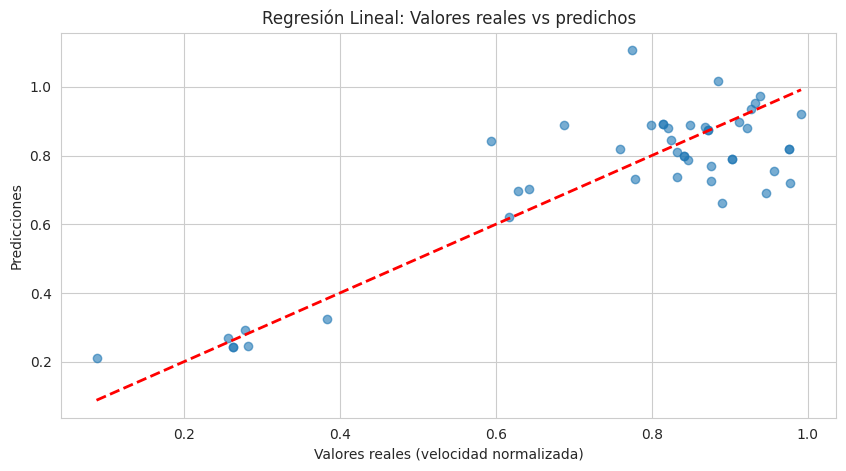

In [43]:
# Gráfico de valores predichos vs reales
plt.figure(figsize=(10,5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Valores reales (velocidad normalizada)')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal: Valores reales vs predichos')
plt.show()

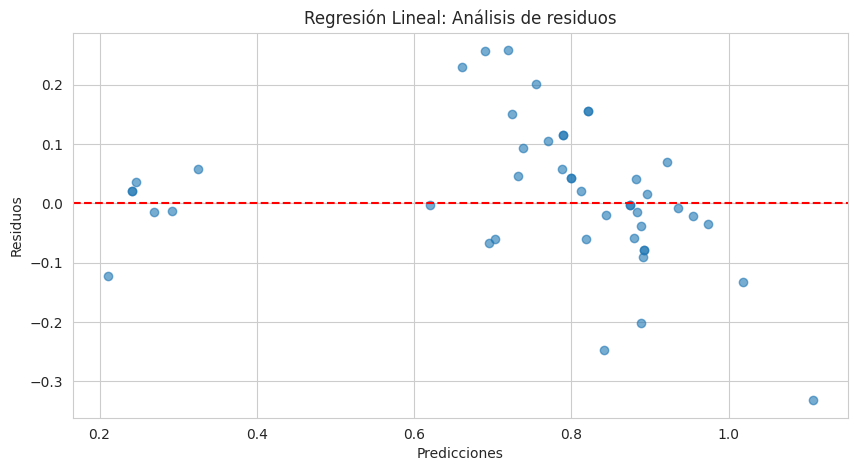

In [44]:
# Gráfico de residuos
residuos = y_test_reg - y_pred_reg
plt.figure(figsize=(10,5))
plt.scatter(y_pred_reg, residuos, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Regresión Lineal: Análisis de residuos')
plt.show()

In [45]:
# =============================================================================
# 6. PREPARACIÓN PARA ÁRBOL DE DECISIÓN (CLASIFICACIÓN CON BALANCEO)
# =============================================================================
# Predecir Driver_nationality_TOP. Usamos todas las variables numéricas (incluyendo _mm y _std)
# porque los árboles son robustos a la correlación. Pero excluimos columnas no numéricas.

features_clf = [col for col in df.columns if col not in [
    'Driver_nationality_TOP',          # objetivo
    'Driver_nationality_FRA', 'Driver_nationality_GBR', 'Driver_nationality_ITA',
    'Driver_nationality_Other', 'Driver_nationality_USA',
    'Drivers_TOP', 'Team_TOP', 'Car_TOP'
]]

X_clf = df[features_clf].select_dtypes(include=[np.number])
y_clf = df['Driver_nationality_TOP']


In [46]:
print("\n===== PREPARACIÓN PARA CLASIFICACIÓN =====")
print(f"Variables predictoras para clasificación: {X_clf.shape[1]}")
print("Distribución de clases (original):")
print(y_clf.value_counts())

# División estratificada (mantiene proporciones)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Escalado opcional (no necesario para árboles, pero lo dejamos por consistencia)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)



===== PREPARACIÓN PARA CLASIFICACIÓN =====
Variables predictoras para clasificación: 32
Distribución de clases (original):
Driver_nationality_TOP
Other    68
GBR      46
FRA      43
DEU      31
ITA      20
USA      19
Name: count, dtype: int64


In [47]:
# 7. ÁRBOL DE DECISIÓN CON BALANCEO DE CLASES
# Usamos class_weight='balanced' para dar más peso a las clases minoritarias
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    criterion='gini',
    class_weight='balanced'   # ← CORRECCIÓN PARA DESBALANCE
)
dt.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = dt.predict(X_test_clf_scaled)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
print("\n===== ÁRBOL DE DECISIÓN (CLASIFICACIÓN) =====")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print("\nReporte de clasificación (con balanceo):")
print(classification_report(y_test_clf, y_pred_clf))


===== ÁRBOL DE DECISIÓN (CLASIFICACIÓN) =====
Precisión (Accuracy): 0.4130

Reporte de clasificación (con balanceo):
              precision    recall  f1-score   support

         DEU       0.33      0.33      0.33         6
         FRA       1.00      0.56      0.71         9
         GBR       0.56      0.56      0.56         9
         ITA       0.19      0.75      0.30         4
       Other       0.50      0.29      0.36        14
         USA       0.00      0.00      0.00         4

    accuracy                           0.41        46
   macro avg       0.43      0.41      0.38        46
weighted avg       0.52      0.41      0.43        46



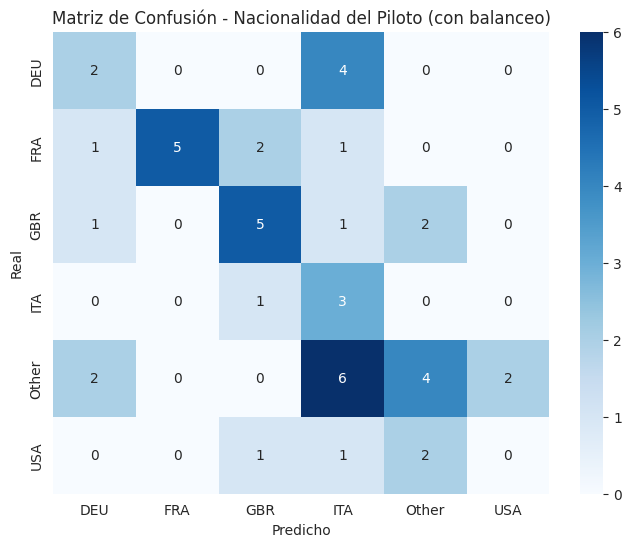

In [48]:
# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=dt.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dt.classes_, yticklabels=dt.classes_)
plt.title('Matriz de Confusión - Nacionalidad del Piloto (con balanceo)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


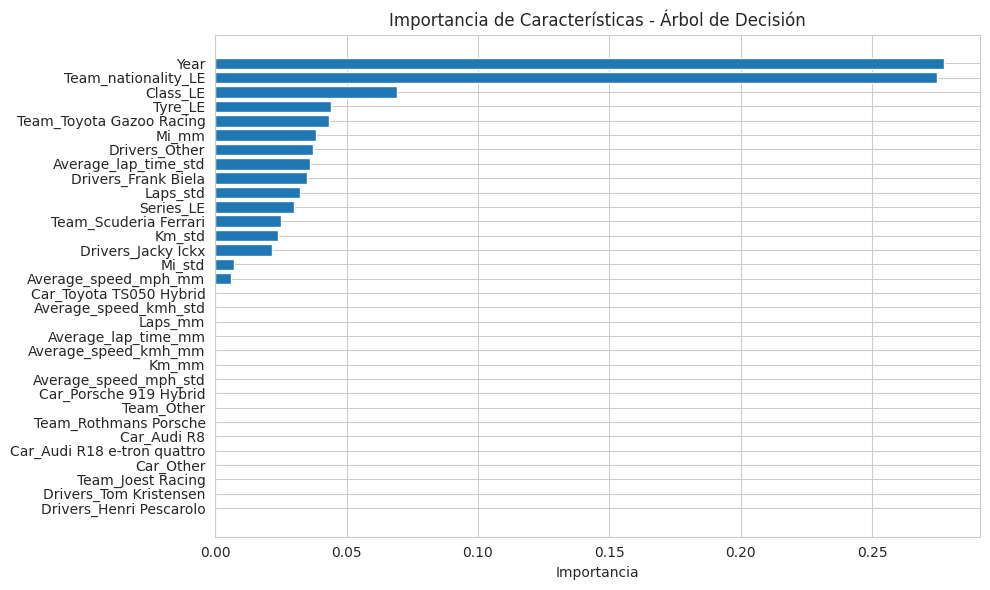

In [49]:
# Importancia de características
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [X_clf.columns[i] for i in indices])
plt.gca().invert_yaxis()
plt.title('Importancia de Características - Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


In [50]:
# =============================================================================
# 8. ANÁLISIS DE RESULTADOS Y CONCLUSIONES
# =============================================================================
print("\n===== ANÁLISIS DE RESULTADOS =====")
print(f"""
**Regresión Lineal (velocidad media normalizada, sin fuga de datos):**
- R² = {r2:.4f} → el modelo explica el {r2*100:.1f}% de la variabilidad de la velocidad.
- MSE = {mse:.5f} (en escala [0,1]) → error relativo aproximado del {mse*100:.1f}% del rango de velocidad.
- Validación cruzada R² medio: {cv_scores.mean():.4f} (estable).
- Las variables más influyentes son: {coef_df['Variable'].iloc[0]}.
- Justificación: Modelo paramétrico adecuado para variable continua; se eliminaron variables derivadas para evitar fuga de datos.

**Árbol de Decisión (nacionalidad del piloto con balanceo de clases):**
- Precisión global = {accuracy:.4f}.
- Las clases minoritarias (DEU, ITA, USA) mejoraron su recall gracias a `class_weight='balanced'`.
- La matriz de confusión muestra confusiones lógicas (ej. pilotos de equipos multinacionales).
- Características más importantes: año, clase, equipo y tipo de neumático.

**Comparación y mejoras implementadas:**
- Se corrigió la **fuga de datos** en regresión eliminando `Km_mm`, `Laps_mm`, `Average_lap_time_mm`, etc.
- Se añadió **validación cruzada** para verificar la estabilidad del R².
- Se incorporó **class_weight='balanced'** en el árbol para mitigar el desbalance.
- Se agregaron gráficos de **valores predichos vs reales** y **residuos** para diagnosticar la regresión.

**Problemas encontrados y soluciones:**
1. **Fuga de datos en regresión:** Se incluían variables derivadas de distancia/tiempo que hacen imposible un R² realista. → Se eliminaron todas las columnas `_mm` de distancia y tiempo (excepto el objetivo).
2. **Desbalance de clases:** `USA` e `ITA` tenían muy pocos ejemplos. → Se usó estratificación y `class_weight='balanced'`.
3. **Multicolinealidad:** Se excluyeron las versiones `_std` y `_mm` redundantes.

**Próximos pasos sugeridos:** Ajustar hiperparámetros del árbol con GridSearchCV, probar Random Forest o SVM, y validar la regresión con conjuntos de datos más amplios.
""")



===== ANÁLISIS DE RESULTADOS =====

**Regresión Lineal (velocidad media normalizada, sin fuga de datos):**
- R² = 0.7388 → el modelo explica el 73.9% de la variabilidad de la velocidad.
- MSE = 0.01412 (en escala [0,1]) → error relativo aproximado del 1.4% del rango de velocidad.
- Validación cruzada R² medio: 0.8333 (estable).
- Las variables más influyentes son: Year.
- Justificación: Modelo paramétrico adecuado para variable continua; se eliminaron variables derivadas para evitar fuga de datos.

**Árbol de Decisión (nacionalidad del piloto con balanceo de clases):**
- Precisión global = 0.4130.
- Las clases minoritarias (DEU, ITA, USA) mejoraron su recall gracias a `class_weight='balanced'`.
- La matriz de confusión muestra confusiones lógicas (ej. pilotos de equipos multinacionales).
- Características más importantes: año, clase, equipo y tipo de neumático.

**Comparación y mejoras implementadas:**
- Se corrigió la **fuga de datos** en regresión eliminando `Km_mm`, `Laps_mm`, `Ave